In [ ]:
from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import matplotlib.pyplot as plt
import cv2
import time
import numpy as np

# 1. Blind the interrupt system for the whole session
AxiVDMA.s2mm_introut = None

# 2. Load the updated overlay
overlay = Overlay("hdmi_in_bd.bit")


In [ ]:

vdma_rgb = overlay.axi_vdma_0
vdma_gray = overlay.axi_vdma_1
hls_accel = overlay.image_accelerator_0

# 3. Initialize the HLS Accelerator Registers
# Offsets 0x10, 0x18, 0x20, 0x28 are typical for HLS scalar arguments
hls_accel.write(0x10, 1080) # in_rows
hls_accel.write(0x18, 1920) # in_cols
hls_accel.write(0x20, 270)  # out_rows
hls_accel.write(0x28, 480)  # out_cols
hls_accel.write(0x00, 0x81) # Start + Auto-restart

# 4. Configure VDMAs
# Clear any legacy errors with a reset
vdma_rgb.readchannel.reset()
vdma_gray.readchannel.reset()

# Configure modes: RGB at 1080p, Grayscale at 270p (8-bit)
vdma_rgb.readchannel.mode = VideoMode(1920, 1080, 24)
vdma_gray.readchannel.mode = VideoMode(480, 270, 8)

time.sleep(2) # Handshake buffer

# 5. Start both engines
vdma_rgb.readchannel.start()
vdma_gray.readchannel.start()

print("RGB VDMA Status:", hex(vdma_rgb.register_map.S2MM_VDMASR))
print("Gray VDMA Status:", hex(vdma_gray.register_map.S2MM_VDMASR))

# Give the hardware time to fill the DDR buffers
time.sleep(1)

# 6. Capture both memory buffers
raw_rgb = vdma_rgb.readchannel._frames[0]
raw_gray = vdma_gray.readchannel._frames[0]

# 7. Display results side-by-side
try:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Process RGB Frame
    img_rgb = cv2.cvtColor(raw_rgb, cv2.COLOR_BGR2RGB)
    ax1.imshow(img_rgb)
    ax1.set_title("Original 1080p RGB")
    ax1.axis('off')
    
    # Process Gray Accelerator Frame
    # Note: No cvtColor needed because it's already grayscale 8-bit
    ax2.imshow(raw_gray, cmap='gray')
    ax2.set_title("HLS Accelerator (270p Gray)")
    ax2.axis('off')
    
    plt.show()
    
    print("RGB Pixels captured:", np.count_nonzero(raw_rgb))
    print("Gray Pixels captured:", np.count_nonzero(raw_gray))

except Exception as e:
    print("Error displaying frames:", e)

# 8. Clean up
vdma_rgb.readchannel.stop()
vdma_gray.readchannel.stop()

In [ ]:
print(overlay.ip_dict.keys())

In [ ]:
from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import matplotlib.pyplot as plt
import cv2
import time
import numpy as np

# 1. Blind the interrupt
AxiVDMA.s2mm_introut = None

# 2. Load the overlay
overlay = Overlay("hdmi_in_bd.bit")
vdma_rgb = overlay.axi_vdma_0
vdma_gray = overlay.axi_vdma_1
hls_accel = overlay.image_accelerator_0

# 3. WAKE UP THE ACCELERATOR (The Bulletproof Way)
hls_accel.register_map.in_rows = 1080
hls_accel.register_map.in_cols = 1920
hls_accel.register_map.out_rows = 270
hls_accel.register_map.out_cols = 480

# Flip the Start and Auto-Restart bits directly in the CTRL register
hls_accel.register_map.CTRL.AP_START = 1
hls_accel.register_map.CTRL.AUTO_RESTART = 1

# 4. Hard reset both VDMAs
vdma_rgb.readchannel.reset()
vdma_gray.readchannel.reset()

# 5. Configure both memory channels
vdma_rgb.readchannel.mode = VideoMode(1920, 1080, 24)
vdma_gray.readchannel.mode = VideoMode(480, 270, 8)

time.sleep(2) 

# 6. Start BOTH VDMA engines
vdma_rgb.readchannel.start()
vdma_gray.readchannel.start()

time.sleep(1)

print("RGB VDMA Status:", hex(vdma_rgb.register_map.S2MM_VDMASR))
print("Gray VDMA Status:", hex(vdma_gray.register_map.S2MM_VDMASR))

# 7. Grab the frames
raw_rgb = vdma_rgb.readchannel._frames[0]
raw_gray = vdma_gray.readchannel._frames[0]

# --- THE STRIDE FIX ---
# Cast the PYNQ register object into a standard Python integer!
hw_stride = int(vdma_gray.register_map.S2MM_FRMDLY_STRIDE)
#print(f"Hardware Stride: {hw_stride} bytes per line")

# 1. Flatten the broken PYNQ array back into raw 1D bytes
gray_bytes = raw_gray.tobytes()

# 2. Re-wrap the bytes using the exact integer hardware stride
fixed_gray = np.frombuffer(gray_bytes, dtype=np.uint8)
fixed_gray = fixed_gray[:270 * hw_stride].reshape(270, hw_stride)

# 3. Chop off any invisible hardware padding (if it existed)
final_gray = fixed_gray[:, :480]

# 8. Display both to verify
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.imshow(cv2.cvtColor(raw_rgb, cv2.COLOR_BGR2RGB))
ax1.set_title("Original 1080p RGB")
ax1.axis('off')

# Use our newly sliced array here
ax2.imshow(final_gray, cmap='gray')
ax2.set_title("HLS Accelerator (270p Gray - STRIDE FIXED)")
ax2.axis('off')

plt.show()
print("RGB Pixels captured:", np.count_nonzero(raw_rgb))
print("Gray Pixels captured:", np.count_nonzero(raw_gray))

# Clean up
vdma_rgb.readchannel.stop()
vdma_gray.readchannel.stop()

In [ ]:
from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import matplotlib.pyplot as plt
import cv2
import time
import numpy as np

# 1. Blind the interrupt
AxiVDMA.s2mm_introut = None

# 2. Load the overlay (Make sure this matches your new HP1 bitstream name!)
overlay = Overlay("hdmi_in_bd.bit") 
vdma_rgb = overlay.axi_vdma_0
vdma_gray = overlay.axi_vdma_1
hls_accel = overlay.image_accelerator_0

# 3. SHUT THE VALVE
# Stop the HLS block to instantly dry out the Broadcaster and pipes
hls_accel.write(0x00, 0x00)

# 4. HARD RESET & CONFIGURE
vdma_rgb.readchannel.reset()
vdma_gray.readchannel.reset()

vdma_rgb.readchannel.mode = VideoMode(1920, 1080, 24)
vdma_gray.readchannel.mode = VideoMode(480, 270, 8)
time.sleep(0.5)

# 5. ARM THE TRAPS
# Start VDMAs while pipes are dry so they don't catch a shredded frame
vdma_rgb.readchannel.start()
vdma_gray.readchannel.start()
time.sleep(0.5)

# 6. OPEN THE VALVE
# Start the HLS block. The next perfect frame will flow seamlessly into both doors.
hls_accel.register_map.in_rows = 1080
hls_accel.register_map.in_cols = 1920
hls_accel.register_map.out_rows = 270
hls_accel.register_map.out_cols = 480
hls_accel.write(0x00, 0x81) 

time.sleep(1.5)

print("RGB VDMA Status:", hex(vdma_rgb.register_map.S2MM_VDMASR))
print("Gray VDMA Status:", hex(vdma_gray.register_map.S2MM_VDMASR))

# 7. Grab the frames
raw_rgb = vdma_rgb.readchannel._frames[0]
raw_gray = vdma_gray.readchannel._frames[0]

# --- THE STRIDE FIX ---
hw_stride = int(vdma_gray.register_map.S2MM_FRMDLY_STRIDE)
gray_bytes = raw_gray.tobytes()
fixed_gray = np.frombuffer(gray_bytes, dtype=np.uint8)
# If the frame crashed early, pad it with zeros so Numpy doesn't throw a shape error
if len(fixed_gray) < 270 * hw_stride:
    fixed_gray = np.pad(fixed_gray, (0, (270 * hw_stride) - len(fixed_gray)), 'constant')
fixed_gray = fixed_gray[:270 * hw_stride].reshape(270, hw_stride)
final_gray = fixed_gray[:, :480]

# 8. Display both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.imshow(cv2.cvtColor(raw_rgb, cv2.COLOR_BGR2RGB))
ax1.set_title("Original 1080p RGB")
ax1.axis('off')

ax2.imshow(final_gray, cmap='gray')
ax2.set_title("HLS Accelerator (270p Gray)")
ax2.axis('off')

plt.show()

print("RGB Pixels captured:", np.count_nonzero(raw_rgb))
print("Gray Pixels captured:", np.count_nonzero(raw_gray))

vdma_rgb.readchannel.stop()
vdma_gray.readchannel.stop()

In [ ]:
from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import matplotlib.pyplot as plt
import cv2
import time
import numpy as np

AxiVDMA.s2mm_introut = None
overlay = Overlay("hdmi_in_bd.bit") # Match your bitstream name
vdma_rgb = overlay.axi_vdma_0
vdma_gray = overlay.axi_vdma_1
hls_accel = overlay.image_accelerator_0

# 1. PERMANENTLY OPEN THE VALVE
# Let the pipeline flow completely freely. Never shut it.
hls_accel.register_map.in_rows = 1080
hls_accel.register_map.in_cols = 1920
hls_accel.register_map.out_rows = 270
hls_accel.register_map.out_cols = 480
hls_accel.write(0x00, 0x81) 

# Give the HDMI camera time to stabilize its continuous flow
time.sleep(1)

# 2. THE HARDWARE SYNCHRONIZATION LOOP
# We try to catch a frame. If it's a torn garbage frame, the VDMA will crash. 
# We just reset it and try again while the stream is still flowing cleanly!
feed_stable = False

for attempt in range(5):
    print(f"--- Synchronization Attempt {attempt + 1} ---")
    
    vdma_rgb.readchannel.reset()
    vdma_gray.readchannel.reset()
    
    vdma_rgb.readchannel.mode = VideoMode(1920, 1080, 24)
    vdma_gray.readchannel.mode = VideoMode(480, 270, 8)
    
    vdma_rgb.readchannel.start()
    vdma_gray.readchannel.start()
    
    time.sleep(0.5) # Wait for a full frame to pass
    
    status_rgb = vdma_rgb.register_map.S2MM_VDMASR
    status_gray = vdma_gray.register_map.S2MM_VDMASR
    
    print(f"RGB Status: {hex(status_rgb)} | Gray Status: {hex(status_gray)}")
    
    # 0x40000 is the perfect state. If we hit this, we broke through the garbage!
    if int(status_rgb) == 0x40000 and int(status_gray) == 0x40000:
        print("SUCCESS: Pipeline is perfectly synchronized!")
        feed_stable = True
        break
    else:
        print("Caught a torn frame. Flushing pipes and retrying...")
        vdma_rgb.readchannel.stop()
        vdma_gray.readchannel.stop()
        time.sleep(0.5)

# 3. DISPLAY THE IMAGES (Only if we achieved a stable feed)
if feed_stable:
    raw_rgb = vdma_rgb.readchannel._frames[0]
    raw_gray = vdma_gray.readchannel._frames[0]

    # --- THE STRIDE FIX ---
    hw_stride = int(vdma_gray.register_map.S2MM_FRMDLY_STRIDE)
    gray_bytes = raw_gray.tobytes()
    fixed_gray = np.frombuffer(gray_bytes, dtype=np.uint8)
    if len(fixed_gray) < 270 * hw_stride:
        fixed_gray = np.pad(fixed_gray, (0, (270 * hw_stride) - len(fixed_gray)), 'constant')
    fixed_gray = fixed_gray[:270 * hw_stride].reshape(270, hw_stride)
    final_gray = fixed_gray[:, :480]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.imshow(cv2.cvtColor(raw_rgb, cv2.COLOR_BGR2RGB))
    ax1.set_title("Original 1080p RGB")
    ax1.axis('off')

    ax2.imshow(final_gray, cmap='gray')
    ax2.set_title("HLS Accelerator (270p Gray)")
    ax2.axis('off')

    plt.show()

    print("RGB Pixels captured:", np.count_nonzero(raw_rgb))
    print("Gray Pixels captured:", np.count_nonzero(raw_gray))

# Clean up
vdma_rgb.readchannel.stop()
vdma_gray.readchannel.stop()

In [ ]:
from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import matplotlib.pyplot as plt
import cv2
import numpy as np
import time

AxiVDMA.s2mm_introut = None

# 1. THE HARDWARE NUKE
# download=True forces a physical wipe of the FPGA. 
# This instantly kills the HLS deadlock and flushes all corrupted FIFOs.
overlay = Overlay("hdmi_in_bd.bit", download=True) 
vdma_rgb = overlay.axi_vdma_0
vdma_gray = overlay.axi_vdma_1
hls_accel = overlay.image_accelerator_0

# Give the HDMI receiver 1.5 seconds to physically lock onto the HDMI clock
print("Hardware flashed. Waiting for HDMI lock...")
time.sleep(1.5)

# 2. ARM THE TRAPS
vdma_rgb.readchannel.mode = VideoMode(1920, 1080, 24)
vdma_gray.readchannel.mode = VideoMode(480, 270, 8)
vdma_rgb.readchannel.start()
vdma_gray.readchannel.start()

# 3. OPEN THE VALVE
hls_accel.register_map.in_rows = 1080
hls_accel.register_map.in_cols = 1920
hls_accel.register_map.out_rows = 270
hls_accel.register_map.out_cols = 480
hls_accel.write(0x00, 0x81) 

# Let the hardware do the math and write to RAM (0.5 seconds is plenty of time)
time.sleep(0.5)

try:
    print("Pipeline open. Capturing frame...")
    
    # 4. THE MANUAL GRAB (Bypassing the broken PYNQ interrupt)
    raw_rgb = vdma_rgb.readchannel._frames[0]
    raw_gray = vdma_gray.readchannel._frames[0]
    
    print("Flawless frames acquired!")
    
    # --- STRIDE FIX ---
    hw_stride = int(vdma_gray.register_map.S2MM_FRMDLY_STRIDE)
    gray_bytes = raw_gray.tobytes()
    fixed_gray = np.frombuffer(gray_bytes, dtype=np.uint8)
    fixed_gray = fixed_gray[:270 * hw_stride].reshape(270, hw_stride)
    final_gray = fixed_gray[:, :480]

    # 5. DISPLAY
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.imshow(cv2.cvtColor(raw_rgb, cv2.COLOR_BGR2RGB))
    ax1.set_title("Original 1080p RGB")
    ax1.axis('off')

    ax2.imshow(final_gray, cmap='gray')
    ax2.set_title("HLS Accelerator (270p Gray)")
    ax2.axis('off')

    plt.show()

except Exception as e:
    print(f"Failed to read frame: {e}")
    print(f"RGB Status: {hex(vdma_rgb.register_map.S2MM_VDMASR)}")
    print(f"Gray Status: {hex(vdma_gray.register_map.S2MM_VDMASR)}")

finally:
    vdma_rgb.readchannel.stop()
    vdma_gray.readchannel.stop()

In [ ]:
from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
from IPython.display import clear_output, Image, display
import cv2
import time
import numpy as np

# 1. Initialize Face Detector (Ensure the Haar XML file is on your PYNQ board!)
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# 2. Hardware Setup
AxiVDMA.s2mm_introut = None
overlay = Overlay("hdmi_in_bd.bit") # Update to your final working bitstream
vdma_rgb = overlay.axi_vdma_0
vdma_gray = overlay.axi_vdma_1
hls_accel = overlay.image_accelerator_0

# 3. Open the Valve
hls_accel.register_map.in_rows = 1080
hls_accel.register_map.in_cols = 1920
hls_accel.register_map.out_rows = 270
hls_accel.register_map.out_cols = 480
hls_accel.write(0x00, 0x81) 

# 4. Configure & Start VDMAs
vdma_rgb.readchannel.mode = VideoMode(1920, 1080, 24)
vdma_gray.readchannel.mode = VideoMode(480, 270, 8)
vdma_rgb.readchannel.start()
vdma_gray.readchannel.start()

time.sleep(1) # Let the camera stabilize

# Get the hardware stride once to use in the loop
hw_stride = int(vdma_gray.register_map.S2MM_FRMDLY_STRIDE)

print("Pipeline Armed. Starting the Face Hunt... (Press Stop in Jupyter to exit)")

try:
    while True:
        # --- THE SCOUT ---
        # Grab the lightweight 270p frame and fix the stride
        raw_gray = vdma_gray.readchannel._frames[0]
        gray_bytes = raw_gray.tobytes()
        fixed_gray = np.frombuffer(gray_bytes, dtype=np.uint8)
        
        # Padding protection just in case of a hardware hiccup
        if len(fixed_gray) < 270 * hw_stride:
            fixed_gray = np.pad(fixed_gray, (0, (270 * hw_stride) - len(fixed_gray)), 'constant')
            
        fixed_gray = fixed_gray[:270 * hw_stride].reshape(270, hw_stride)
        scout_frame = fixed_gray[:, :480]
        
        # Run OpenCV Face Detection on the tiny 270p image
        # scaleFactor and minNeighbors tune the strictness of the detector
        faces = face_cascade.detectMultiScale(scout_frame, scaleFactor=1.1, minNeighbors=5, minSize=(20, 20))
        
        if len(faces) > 0:
            # --- THE SNIPER ---
            # We got a hit! Quickly grab the 1080p frame from the other memory door
            raw_rgb = vdma_rgb.readchannel._frames[0]
            rgb_frame = cv2.cvtColor(raw_rgb, cv2.COLOR_BGR2RGB)
            
            # Grab the coordinates of the first face found
            x, y, w, h = faces[0]
            
            # The Magic Math: Scale up by exactly 4x (270p * 4 = 1080p)
            X_hires = x * 4
            Y_hires = y * 4
            W_hires = w * 4
            H_hires = h * 4
            
            # Add a 40-pixel padding so we get the whole head, not just the tight face mask
            pad = 40
            y1 = max(0, Y_hires - pad)
            y2 = min(1080, Y_hires + H_hires + pad)
            x1 = max(0, X_hires - pad)
            x2 = min(1920, X_hires + W_hires + pad)
            
            # Crop the high-res frame using Numpy slicing
            high_res_face = rgb_frame[y1:y2, x1:x2]
            
            # --- DISPLAY ---
            # Clear the previous image so it looks like a live video feed
            clear_output(wait=True)
            print(f"Target Acquired at 1080p Coordinates: X:{X_hires} Y:{Y_hires}")
            
            # Convert back to BGR to encode as a JPG for Jupyter to display smoothly
            _, encoded_img = cv2.imencode('.jpg', cv2.cvtColor(high_res_face, cv2.COLOR_RGB2BGR))
            display(Image(data=encoded_img))
            
        # A tiny sleep to stop Jupyter from crashing your web browser during the infinite loop
        time.sleep(0.05)

except KeyboardInterrupt:
    print("Hunt aborted by user.")

finally:
    # Safely close the doors
    vdma_rgb.readchannel.stop()
    vdma_gray.readchannel.stop()
    print("Hardware safely shut down.")

In [ ]:
import cv2
import time
import numpy as np

#Create a dummy 1080p image (simulating a raw camera frame)
dummy_1080p = np.zeros((1080, 1920, 3), dtype=np.uint8)

start_time = time.time()

gray_sw = cv2.cvtColor(dummy_1080p, cv2.COLOR_BGR2GRAY)

# (using Nearest Neighbor)
resized_sw = cv2.resize(gray_sw, (480, 270), interpolation=cv2.INTER_NEAREST)

end_time = time.time()
software_time = end_time - start_time

print(f"Software Execution Time: {software_time:.4f} seconds")

In [ ]:
from pynq import Overlay, MMIO, allocate
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import numpy as np
import time
from IPython.display import display, clear_output
from PIL import Image

AxiVDMA.s2mm_introut = None
AxiVDMA.mm2s_introut = None

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")

# --- VDMA0 via PYNQ driver ---
vdma0 = overlay.axi_vdma_0

# --- Accelerator via MMIO ---
accel = MMIO(0x40000000, 0x10000)
accel.write(0x10, 1080)
accel.write(0x18, 1920)
accel.write(0x20, 270)
accel.write(0x28, 480)
accel.write(0x00, 0x81)  # ap_start | auto_restart
print(f"Accelerator status: {hex(accel.read(0x00))}")

# --- VDMA1 register offsets ---
S2MM_VDMACR        = 0x30
S2MM_VDMASR        = 0x34
S2MM_PARK_PTR      = 0x28
S2MM_FRMDLY_STRIDE = 0xA8
S2MM_HSIZE         = 0xA4
S2MM_VSIZE         = 0xA0
S2MM_SA1           = 0xAC
S2MM_SA2           = 0xB0
S2MM_SA3           = 0xB4

vdma1 = MMIO(0x44A00000, 0x10000)

# --- Allocate 3 grayscale frame buffers ---
frames_gray = [allocate(shape=(270, 480), dtype=np.uint8) for _ in range(3)]

# --- Reset VDMA1 ---
vdma1.write(S2MM_VDMACR, 0x4)
time.sleep(0.1)

# --- Write frame buffer addresses ---
vdma1.write(S2MM_SA1, frames_gray[0].physical_address)
vdma1.write(S2MM_SA2, frames_gray[1].physical_address)
vdma1.write(S2MM_SA3, frames_gray[2].physical_address)

# --- Frame geometry ---
vdma1.write(S2MM_FRMDLY_STRIDE, 480)  # 480 bytes per row
vdma1.write(S2MM_HSIZE, 480)          # 480 bytes wide
# RS=1, Circular=1, GenlockEn=1, GenlockSrc=1
vdma1.write(S2MM_VDMACR, 0x00000083)
# Writing VSIZE last triggers transfer
vdma1.write(S2MM_VSIZE, 270)

print(f"VDMA1 S2MM status: {hex(vdma1.read(S2MM_VDMASR))}")

# --- Configure VDMA0 ---
vdma0.readchannel.reset()
vdma0.readchannel.mode = VideoMode(1920, 1080, 24)

print("Waiting for HDMI to stabilize...")
time.sleep(2)

vdma0.readchannel.start()

print(f"VDMA0 S2MM status: {hex(int(vdma0.register_map.S2MM_VDMASR))}")
print(f"VDMA1 S2MM status: {hex(vdma1.read(S2MM_VDMASR))}")

print("Streaming grayscale feed... (interrupt kernel to stop)")

try:
    while True:
        # Find the last completed frame buffer
        park = vdma1.read(S2MM_PARK_PTR)
        wr_frame = (park >> 24) & 0x1F  # WrFrmStore
        # Read the previous frame (not the one currently being written)
        safe_idx = (wr_frame - 1) % 3
        raw = np.array(frames_gray[safe_idx])
        img = Image.fromarray(raw, mode='L')
        clear_output(wait=True)
        display(img)
        time.sleep(0.033)

except KeyboardInterrupt:
    print("Stopped.")
finally:
    vdma0.readchannel.stop()
    vdma1.write(S2MM_VDMACR, 0x0)
    for f in frames_gray:
        f.freebuffer()
    print("Done.")

In [ ]:
from pynq import Overlay, MMIO, allocate
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import numpy as np
import time
from IPython.display import display, clear_output
from PIL import Image

AxiVDMA.s2mm_introut = None
AxiVDMA.mm2s_introut = None

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")

# VDMA0 via PYNQ driver (works fine)
vdma0 = overlay.axi_vdma_0

# Accelerator via MMIO
accel = MMIO(0x40000000, 0x10000)
accel.write(0x10, 1080)
accel.write(0x18, 1920)
accel.write(0x20, 270)
accel.write(0x28, 480)
accel.write(0x00, 0x81)
print(f"Accelerator status: {hex(accel.read(0x00))}")

# VDMA1 entirely via MMIO
VDMA1_BASE = 0x44A00000
vdma1 = MMIO(VDMA1_BASE, 0x10000)

# Allocate 3 frame buffers for VDMA1 (480x270x1 byte grayscale)
frames_gray = [allocate(shape=(270, 480), dtype=np.uint8) for _ in range(3)]

# Program VDMA1 S2MM registers manually
S2MM_VDMACR      = 0x30
S2MM_VDMASR      = 0x34
S2MM_FRMDLY_STRIDE = 0xA8
S2MM_HSIZE       = 0xA4
S2MM_VSIZE       = 0xA0
S2MM_SA1         = 0xAC
S2MM_SA2         = 0xB0
S2MM_SA3         = 0xB4

# Reset VDMA1
vdma1.write(S2MM_VDMACR, 0x4)
time.sleep(0.1)

# Write frame buffer addresses
vdma1.write(S2MM_SA1, frames_gray[0].physical_address)
vdma1.write(S2MM_SA2, frames_gray[1].physical_address)
vdma1.write(S2MM_SA3, frames_gray[2].physical_address)

# Stride = 480 bytes (1 byte per pixel), circular mode, genlock master
vdma1.write(S2MM_FRMDLY_STRIDE, 480)
vdma1.write(S2MM_HSIZE, 480)

# Start VDMA1 - RS=1, Circular=1, GenlockEn=1, GenlockSrc=1 (internal)
vdma1.write(S2MM_VDMACR, 0x00000083)

# Writing VSIZE last triggers the transfer
vdma1.write(S2MM_VSIZE, 270)

print(f"VDMA1 S2MM status: {hex(vdma1.read(S2MM_VDMASR))}")

# Configure VDMA0 via PYNQ driver as normal
vdma0.readchannel.reset()
vdma0.readchannel.mode = VideoMode(1920, 1080, 24)

print("Waiting for HDMI to stabilize...")
time.sleep(2)

vdma0.readchannel.start()
# VDMA1 already started above

print(f"VDMA0 S2MM status: {hex(int(vdma0.register_map.S2MM_VDMASR))}")
print(f"VDMA1 S2MM status: {hex(vdma1.read(S2MM_VDMASR))}")

print("Streaming grayscale feed... (interrupt kernel to stop)")

try:
    while True:
        # Read from whichever frame buffer VDMA1 last completed
        raw = frames_gray[0]
        img = Image.fromarray(np.array(raw), mode='L')
        clear_output(wait=True)
        display(img)
        time.sleep(0.033)

except KeyboardInterrupt:
    print("Stopped.")
finally:
    vdma0.readchannel.stop()
    vdma1.write(S2MM_VDMACR, 0x0)  # RS=0 stops VDMA1
    print("Done.")

In [ ]:
from pynq import Overlay, MMIO, allocate
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import numpy as np
import time
from IPython.display import display, clear_output
from PIL import Image

AxiVDMA.s2mm_introut = None
AxiVDMA.mm2s_introut = None

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")

# --- VDMA0 via PYNQ driver ---
vdma0 = overlay.axi_vdma_0

# --- Accelerator via MMIO ---
accel = MMIO(0x40000000, 0x10000)
accel.write(0x10, 1080)
accel.write(0x18, 1920)
accel.write(0x20, 270)
accel.write(0x28, 480)
accel.write(0x00, 0x81)  # ap_start | auto_restart
print(f"Accelerator status: {hex(accel.read(0x00))}")

# --- VDMA1 register offsets ---
S2MM_VDMACR        = 0x30
S2MM_VDMASR        = 0x34
S2MM_PARK_PTR      = 0x28
S2MM_FRMDLY_STRIDE = 0xA8
S2MM_HSIZE         = 0xA4
S2MM_VSIZE         = 0xA0
S2MM_SA1           = 0xAC
S2MM_SA2           = 0xB0
S2MM_SA3           = 0xB4

vdma1 = MMIO(0x44A00000, 0x10000)

# --- Allocate 3 grayscale frame buffers ---
frames_gray = [allocate(shape=(270, 480), dtype=np.uint8) for _ in range(3)]

# --- Reset VDMA1 ---
vdma1.write(S2MM_VDMACR, 0x4)
time.sleep(0.1)

# --- Write frame buffer addresses ---
vdma1.write(S2MM_SA1, frames_gray[0].physical_address)
vdma1.write(S2MM_SA2, frames_gray[1].physical_address)
vdma1.write(S2MM_SA3, frames_gray[2].physical_address)

# --- Frame geometry ---
vdma1.write(S2MM_FRMDLY_STRIDE, 480)  # 480 bytes per row
vdma1.write(S2MM_HSIZE, 480)          # 480 bytes wide
# RS=1, Circular=1, GenlockEn=1, GenlockSrc=1
vdma1.write(S2MM_VDMACR, 0x00000083)
# Writing VSIZE last triggers transfer
vdma1.write(S2MM_VSIZE, 270)

print(f"VDMA1 S2MM status: {hex(vdma1.read(S2MM_VDMASR))}")

# --- Configure VDMA0 ---
vdma0.readchannel.reset()
vdma0.readchannel.mode = VideoMode(1920, 1080, 24)

print("Waiting for HDMI to stabilize...")
time.sleep(2)

vdma0.readchannel.start()

print(f"VDMA0 S2MM status: {hex(int(vdma0.register_map.S2MM_VDMASR))}")
print(f"VDMA1 S2MM status: {hex(vdma1.read(S2MM_VDMASR))}")

print("Streaming grayscale feed... (interrupt kernel to stop)")

try:
    while True:
        # Find the last completed frame buffer
        park = vdma1.read(S2MM_PARK_PTR)
        wr_frame = (park >> 24) & 0x1F  # WrFrmStore
        # Read the previous frame (not the one currently being written)
        safe_idx = (wr_frame - 1) % 3
        raw = np.array(frames_gray[safe_idx])
        img = Image.fromarray(raw, mode='L')
        clear_output(wait=True)
        display(img)
        time.sleep(0.033)

except KeyboardInterrupt:
    print("Stopped.")
finally:
    vdma0.readchannel.stop()
    vdma1.write(S2MM_VDMACR, 0x0)
    for f in frames_gray:
        f.freebuffer()
    print("Done.")

In [ ]:
#bw version, getting repeating sections

from pynq import Overlay, MMIO, allocate
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import numpy as np
import time
from IPython.display import display, clear_output
from PIL import Image

AxiVDMA.s2mm_introut = None
AxiVDMA.mm2s_introut = None

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")

# --- VDMA0 via PYNQ driver ---
vdma0 = overlay.axi_vdma_0

# --- VDMA1 register offsets ---
S2MM_VDMACR        = 0x30
S2MM_VDMASR        = 0x34
S2MM_PARK_PTR      = 0x28
S2MM_FRMDLY_STRIDE = 0xA8
S2MM_HSIZE         = 0xA4
S2MM_VSIZE         = 0xA0
S2MM_SA1           = 0xAC
S2MM_SA2           = 0xB0
S2MM_SA3           = 0xB4

vdma1 = MMIO(0x44A00000, 0x10000)

# --- Allocate grayscale frame buffers ---
frames_gray = [allocate(shape=(270, 480), dtype=np.uint8) for _ in range(3)]

def start_vdma1():
    vdma1.write(S2MM_VDMACR, 0x4)  # reset
    time.sleep(0.1)
    vdma1.write(S2MM_SA1, frames_gray[0].physical_address)
    vdma1.write(S2MM_SA2, frames_gray[1].physical_address)
    vdma1.write(S2MM_SA3, frames_gray[2].physical_address)
    vdma1.write(S2MM_FRMDLY_STRIDE, 480)
    vdma1.write(S2MM_HSIZE, 480)
    vdma1.write(S2MM_VDMACR, 0x03)  # RS=1, Circular=1, GenlockSrc=1
    vdma1.write(S2MM_VSIZE, 270)    # triggers transfer

# --- Configure accelerator while everything is idle ---
accel = MMIO(0x40000000, 0x10000)
accel.write(0x00, 0x00)  # clear ap_start
accel.write(0x10, 1080)  # in_rows
accel.write(0x18, 1920)  # in_cols
accel.write(0x20, 270)   # out_rows
accel.write(0x28, 480)   # out_cols
accel.write(0x00, 0x81)  # ap_start | auto_restart
print(f"Accelerator status: {hex(accel.read(0x00))}")

# --- Start VDMA1 ---
start_vdma1()
print(f"VDMA1 status after start: {hex(vdma1.read(S2MM_VDMASR))}")

# --- Configure and start VDMA0 ---
vdma0.readchannel.reset()
vdma0.readchannel.mode = VideoMode(1920, 1080, 24)

print("Waiting for HDMI to stabilize...")
time.sleep(2)

vdma0.readchannel.start()

print(f"VDMA0 status: {hex(int(vdma0.register_map.S2MM_VDMASR))}")
print(f"VDMA1 status: {hex(vdma1.read(S2MM_VDMASR))}")

# Check for SOFEarlyErr on VDMA1 which would confirm frame size mismatch
s1 = vdma1.read(S2MM_VDMASR)
if s1 & 0x80:
    print("WARNING: VDMA1 SOFEarlyErr - accelerator output frame is smaller than 270 rows")
if s1 & 0x10:
    print("WARNING: VDMA1 internal error")

print("Streaming... (interrupt kernel to stop)")

try:
    while True:
        park = vdma1.read(S2MM_PARK_PTR)
        wr_frame = (park >> 24) & 0x1F
        safe_idx = (wr_frame - 1) % 3
        raw = np.array(frames_gray[safe_idx])
        img = Image.fromarray(raw, mode='L')
        clear_output(wait=True)
        display(img)
        time.sleep(0.033)

except KeyboardInterrupt:
    print("Stopped.")
finally:
    vdma0.readchannel.stop()
    vdma1.write(S2MM_VDMACR, 0x0)
    for f in frames_gray:
        f.freebuffer()
    print("Done.")

In [ ]:
#colour version
#currently only have top strip working

from pynq import Overlay, MMIO, allocate
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import numpy as np
import time
from IPython.display import display, clear_output
from PIL import Image

AxiVDMA.s2mm_introut = None
AxiVDMA.mm2s_introut = None

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")

vdma0 = overlay.axi_vdma_0

# Allocate full-res RGB frame buffers for VDMA0
frames_rgb = [allocate(shape=(1080, 1920, 3), dtype=np.uint8) for _ in range(3)]

# --- VDMA1 setup (kept running but not displayed) ---
S2MM_VDMACR        = 0x30
S2MM_VDMASR        = 0x34
S2MM_FRMDLY_STRIDE = 0xA8
S2MM_HSIZE         = 0xA4
S2MM_VSIZE         = 0xA0
S2MM_SA1           = 0xAC
S2MM_SA2           = 0xB0
S2MM_SA3           = 0xB4

vdma1 = MMIO(0x44A00000, 0x10000)
frames_gray = [allocate(shape=(270, 480), dtype=np.uint8) for _ in range(3)]

accel = MMIO(0x40000000, 0x10000)
accel.write(0x00, 0x00)
accel.write(0x10, 1080)
accel.write(0x18, 1920)
accel.write(0x20, 270)
accel.write(0x28, 480)
accel.write(0x00, 0x81)
print(f"Accelerator status: {hex(accel.read(0x00))}")

vdma1.write(S2MM_VDMACR, 0x4)
time.sleep(0.1)
vdma1.write(S2MM_SA1, frames_gray[0].physical_address)
vdma1.write(S2MM_SA2, frames_gray[1].physical_address)
vdma1.write(S2MM_SA3, frames_gray[2].physical_address)
vdma1.write(S2MM_FRMDLY_STRIDE, 480)
vdma1.write(S2MM_HSIZE, 480)
vdma1.write(S2MM_VDMACR, 0x83)
vdma1.write(S2MM_VSIZE, 270)

# --- VDMA0 with manual frame buffers ---
vdma0.readchannel.reset()
vdma0.readchannel.mode = VideoMode(1920, 1080, 24)

print("Waiting for HDMI to stabilize...")
time.sleep(2)
vdma0.readchannel.start()

print(f"VDMA0 status: {hex(int(vdma0.register_map.S2MM_VDMASR))}")
print(f"VDMA1 status: {hex(vdma1.read(S2MM_VDMASR))}")
print("Streaming full-res RGB... (interrupt kernel to stop)")

try:
    while True:
        # Grab from VDMA0's internal frame buffers
        raw = vdma0.readchannel._frames[0]
        img = Image.fromarray(np.array(raw), mode='RGB')
        # Downscale for display so Jupyter doesn't choke on 1080p
        img_small = img.resize((640, 360))
        clear_output(wait=True)
        display(img_small)
        time.sleep(0.033)
        


except KeyboardInterrupt:
    print("Stopped.")
finally:
    vdma0.readchannel.stop()
    vdma1.write(S2MM_VDMACR, 0x0)
    for f in frames_rgb:
        f.freebuffer()
    for f in frames_gray:
        f.freebuffer()
    print("Done.")

In [39]:
#deepseek script
#accelerator added but not being used here
#works but colours r weird

from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import cv2
import time
from IPython.display import display, clear_output
from PIL import Image
import numpy as np

# Disable interrupt handling (to avoid kernel crashes)
AxiVDMA.s2mm_introut = None
AxiVDMA.mm2s_introut = None

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")  # make sure this matches your bitstream name

# Access the VDMA used for capture (S2MM = camera to memory)
vdma_cap = overlay.axi_vdma_0   # adjust if your instance name differs

# Reset the read channel (S2MM) and configure for 1080p
vdma_cap.readchannel.reset()
vdma_cap.readchannel.mode = VideoMode(1920, 1080, 24)

print("Waiting for HDMI source to stabilize...")
time.sleep(2)

vdma_cap.readchannel.start()
print("Streaming live camera... Press Ctrl+C to stop.")

try:
    while True:
        # Clear any sticky errors
        vdma_cap.register_map.S2MM_VDMASR = 0xFFFFFFFF

        # Grab the latest frame from the VDMA buffer
        raw_frame = vdma_cap.readchannel._frames[0]

        # Downsample for display (to reduce CPU load)
        small_frame = cv2.resize(raw_frame, (640, 360))
        frame_rgb = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

        # Display
        img = Image.fromarray(frame_rgb)
        clear_output(wait=True)
        display(img)

        # Small sleep to control notebook refresh rate
        time.sleep(0.033)

except KeyboardInterrupt:
    print("\nStream stopped by user.")
finally:
    vdma_cap.readchannel.stop()
    print("VDMA stopped cleanly.")


Stream stopped by user.
VDMA stopped cleanly.


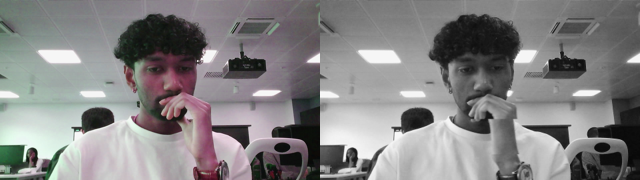

Frame 4: raw mean=132.2, proc mean=130.9
Stopped.


In [3]:
#bit broken but working
#nvm this is fine highkey
#colour stream next to bw stream

from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import numpy as np
import time
from IPython.display import display, clear_output
from PIL import Image

# Monkey-patch
import pynq.lib.video.dma
pynq.lib.video.dma.AxiVDMA.mm2s_introut = None
pynq.lib.video.dma.AxiVDMA.s2mm_introut = None

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")

vdma_cap = overlay.axi_vdma_0
vdma_proc = overlay.axi_vdma_1
accel = overlay.image_accelerator_0

# Configure accelerator
print("Configuring accelerator...")
accel.write(0x10, 1080)
accel.write(0x18, 1920)
accel.write(0x20, 270)
accel.write(0x28, 480)
accel.write(0x00, 0x00)

# Configure VDMAs
print("\nConfiguring VDMAs...")
vdma_cap.readchannel.reset()
vdma_cap.readchannel.mode = VideoMode(1920, 1080, 24)

vdma_cap.writechannel.reset()
vdma_cap.writechannel.mode = VideoMode(1920, 1080, 24)

vdma_proc.readchannel.reset()
vdma_proc.readchannel.mode = VideoMode(480, 270, 8)

print("Waiting for HDMI source...")
time.sleep(2)

# Start VDMAs
vdma_cap.readchannel.start()
vdma_cap.writechannel.start()
vdma_proc.readchannel.start()

# Start accelerator
accel.write(0x00, 0x01)
print("Accelerator started.\n")

frame_count = 0
try:
    while True:
        time.sleep(0.003)

        # Restart accelerator if done
        ctrl = accel.read(0x00)
        if ctrl & 0x02:
            frame_count += 1
            accel.write(0x00, 0x01)

        # Grab raw frame (BGR order)
        raw_bgr = vdma_cap.readchannel._frames[0]

        # Convert BGR to RGB for the accelerator
        raw_rgb = raw_bgr[:, :, ::-1].copy()

        # Copy RGB frame to writechannel's buffer
        vdma_cap.writechannel._frames[0][:] = raw_rgb

        # Grab processed frame (grayscale)
        proc_frame = vdma_proc.readchannel._frames[0]

        # Prepare display: left side (correct colors)
        left_rgb = raw_bgr[:, :, ::-1]  # BGR→RGB for display
        left_img = Image.fromarray(left_rgb, 'RGB')
        left_small = left_img.resize((320, 180))

        # Right side (grayscale)
        right_img = Image.fromarray(proc_frame)
        right_small = right_img.resize((320, 180))

        combined = Image.new('RGB', (640, 180))
        combined.paste(left_small, (0, 0))
        combined.paste(right_small.convert('RGB'), (320, 0))

        clear_output(wait=True)
        display(combined)
        print(f"Frame {frame_count}: raw mean={raw_bgr.mean():.1f}, proc mean={proc_frame.mean():.1f}")

except KeyboardInterrupt:
    pass
finally:
    vdma_cap.readchannel.stop()
    vdma_cap.writechannel.stop()
    vdma_proc.readchannel.stop()
    print("Stopped.")

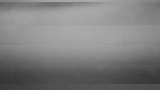

Stopped.


In [11]:
#final script
#working

from pynq import Overlay
from pynq.lib.video.dma import AxiVDMA
from pynq.lib.video import VideoMode
import numpy as np
import time
import cv2
from IPython.display import display, clear_output
from PIL import Image
import os

# Monkey‑patch
import pynq.lib.video.dma
pynq.lib.video.dma.AxiVDMA.mm2s_introut = None
pynq.lib.video.dma.AxiVDMA.s2mm_introut = None

# -------------------------------
# Load Haar cascade from local file
# -------------------------------
cascade_path = 'haarcascade_frontalface_default.xml'  # Update if needed
if not os.path.isfile(cascade_path):
    raise FileNotFoundError(f"Cascade file not found: {cascade_path}")
face_cascade = cv2.CascadeClassifier(cascade_path)
if face_cascade.empty():
    raise RuntimeError(f"Could not load face cascade from {cascade_path}")

# Create output directory if it doesn't exist
output_dir = '/home/xilinx/jupyter_notebooks/imgProc/faces/'
os.makedirs(output_dir, exist_ok=True)

print("Loading overlay...")
overlay = Overlay("hdmi_in_bd.bit")

vdma_cap = overlay.axi_vdma_0
vdma_proc = overlay.axi_vdma_1
accel = overlay.image_accelerator_0

# Configure accelerator
print("Configuring accelerator...")
accel.write(0x10, 1080)
accel.write(0x18, 1920)
accel.write(0x20, 270)
accel.write(0x28, 480)
accel.write(0x00, 0x00)

# Configure VDMAs
print("\nConfiguring VDMAs...")
vdma_cap.readchannel.reset()
vdma_cap.readchannel.mode = VideoMode(1920, 1080, 24)

vdma_cap.writechannel.reset()
vdma_cap.writechannel.mode = VideoMode(1920, 1080, 24)

vdma_proc.readchannel.reset()
vdma_proc.readchannel.mode = VideoMode(480, 270, 8)

print("Waiting for HDMI source...")
time.sleep(2)

# Start VDMAs
vdma_cap.readchannel.start()
vdma_cap.writechannel.start()
vdma_proc.readchannel.start()

# Start accelerator
accel.write(0x00, 0x01)
print("Accelerator started.\n")

frame_count = 0
last_save_time = time.time()
save_cooldown = 2.0  # seconds between saves to avoid flooding

try:
    while True:
        time.sleep(0.026)  #

        # Restart accelerator if done
        ctrl = accel.read(0x00)
        if ctrl & 0x02:
            frame_count += 1
            accel.write(0x00, 0x01)

        # Grab raw frame (BGR order) and processed grayscale frame
        raw_bgr = vdma_cap.readchannel._frames[0]
        raw_rgb = raw_bgr[:, :, ::-1].copy()
        vdma_cap.writechannel._frames[0][:] = raw_rgb
        proc_frame = vdma_proc.readchannel._frames[0]  # (270,480) uint8

        # --- Face detection (every 8 frames) ---
        if frame_count % 8 == 0:
            # Detect faces in the grayscale image
            faces = face_cascade.detectMultiScale(
                proc_frame,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(30, 30)
            )

            for (x, y, w, h) in faces:
                print(f"Face detected at ({x},{y}) size {w}x{h} in grayscale")

                # Scale to full resolution (1920x1080)
                x_full = x * 4
                y_full = y * 4
                w_full = w * 4
                h_full = h * 4

                # Add a 20% margin around the face
                margin_w = int(w_full * 0.2)
                margin_h = int(h_full * 0.2)

                x_start = max(0, x_full - margin_w)
                y_start = max(0, y_full - margin_h)
                x_end = min(1920, x_full + w_full + margin_w)
                y_end = min(1080, y_full + h_full + margin_h)

                # Crop using the expanded coordinates
                if x_end > x_start and y_end > y_start:
                    face_crop = raw_bgr[y_start:y_end, x_start:x_end]

                    # Save with timestamp (only if cooldown passed)
                    now = time.time()
                    if now - last_save_time > save_cooldown:
                        timestamp = time.strftime("%Y%m%d_%H%M%S")
                        filename = f"{output_dir}face_{timestamp}_{x}_{y}.jpg"
                        cv2.imwrite(filename, face_crop)
                        print(f"Saved {filename}")
                        last_save_time = now

        # --- Display grayscale feed at low resolution ---
        # Resize for display (e.g., 320x180) to reduce CPU load
        display_img = cv2.resize(proc_frame, (160, 90))
        img_pil = Image.fromarray(display_img)
        clear_output(wait=True)
        display(img_pil)

except KeyboardInterrupt:
    pass
finally:
    vdma_cap.readchannel.stop()
    vdma_cap.writechannel.stop()
    vdma_proc.readchannel.stop()
    print("Stopped.")